LIBRARIES

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

DATA LOADING

In [155]:
from google.colab import files
uploaded = files.upload()


Saving data_training.csv to data_training (4).csv
Saving data_testing.csv to data_testing (4).csv


In [156]:
train_df = pd.read_csv('/content/data_training.csv')
test_df = pd.read_csv('/content/data_testing.csv')

print("Training Shape :", train_df.shape)
print("Testing Shape :", test_df.shape)

train_df.head()

Training Shape : (857, 13)
Testing Shape : (286, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


DATA OVERVIEW

In [157]:
# =========================
# Menampilkan Struktur Data
# =========================

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


Berdasarkan hasil pengecekan struktur dataset menggunakan info(), dataset memiliki 857 baris data (entries) dan 13 variabel (columns). Seluruh variabel memiliki jumlah non-null sebanyak 857.

In [158]:
# =========================
# Menampilkan Statistik Deskriptif
# =========================

print()
print("Descriptive Statistics")
train_df.describe().round(2)


Descriptive Statistics


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.00,857.00,857.00,857.00,857.00,857.00,857.00,857.00,857.00,857.00,857.00,857.00,857.00
mean,8.26,0.53,0.27,2.51,0.09,15.78,45.98,1.00,3.31,0.66,10.43,5.65,813.75
std,1.70,0.18,0.20,1.29,0.05,10.30,31.69,0.00,0.15,0.17,1.07,0.82,463.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.39,8.40,3.00,0.00
25%,7.10,0.40,0.09,1.90,0.07,7.00,21.00,1.00,3.21,0.55,9.50,5.00,413.00
50%,7.90,0.52,0.25,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00,814.00
75%,9.10,0.64,0.42,2.60,0.09,21.00,63.00,1.00,3.40,0.73,11.10,6.00,1214.00
max,15.60,1.58,1.00,15.50,0.61,68.00,278.00,1.00,4.01,2.00,14.00,8.00,1597.00


Berdasarkan hasil statistik deskriptif, dataset wine quality terdiri dari 857 data dengan 13 variabel yang memiliki karakteristik numerik yang beragam. Beberapa fitur seperti residual sugar dan total sulfur dioxide menunjukkan penyebaran data yang cukup tinggi, sedangkan density memiliki variasi yang relatif kecil. Variabel alcohol memiliki rata-rata sebesar 10.43, sementara variabel quality berada pada rentang 3 hingga 8 dengan rata-rata 5.65, yang menunjukkan bahwa sebagian besar wine berada pada kategori kualitas menengah. Variabel Id hanya berfungsi sebagai identitas data dan tidak digunakan dalam proses pemodelan machine learning.


In [159]:
# =========================
# Menampilkan Missing value
# =========================

missing = train_df.isnull().sum()
missing = missing[missing > 0].reset_index()
missing.columns = ['Feature', 'Missing Count']
missing['Missing %'] = (missing['Missing Count'] / len(train_df) * 100).round(2)
print(missing.to_string(index=False))

Empty DataFrame
Columns: [Feature, Missing Count, Missing %]
Index: []


In [160]:
# =========================
# Menampilkan Data Duplikat
# =========================

print("Jumlah Duplikat:", train_df.duplicated().sum())

Jumlah Duplikat: 0


TARGET DISTRIBUTION

Sebelum dilakukan proses pemodelan machine learning, terlebih dahulu dilakukan analisis distribusi data pada variabel target yaitu `quality`. Visualisasi distribusi ini bertujuan untuk mengetahui jumlah data pada setiap kategori kualitas wine yang terdapat dalam dataset. Dengan memahami persebaran data target, peneliti dapat mengidentifikasi apakah dataset memiliki distribusi yang seimbang (*balanced*) atau tidak seimbang (*imbalanced*). Kondisi distribusi data sangat penting untuk diperhatikan karena dapat mempengaruhi performa model klasifikasi yang akan dibangun. Pada tahap ini digunakan visualisasi *countplot* untuk menampilkan frekuensi masing-masing kategori kualitas wine sehingga pola persebaran data dapat diamati dengan lebih jelas.


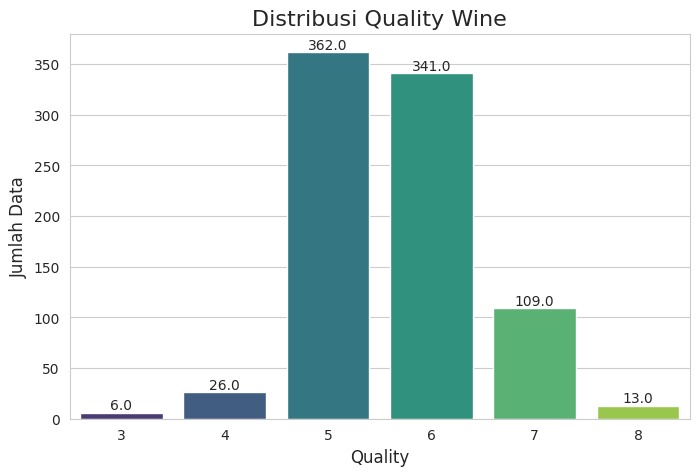

In [161]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='quality',
    data=train_df,
    palette='viridis'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (
            p.get_x() + p.get_width()/2.,
            p.get_height()
        ),
        ha='center',
        va='bottom'
    )

plt.title('Distribusi Quality Wine')
plt.xlabel('Quality')
plt.ylabel('Jumlah Data')

plt.show()

Berdasarkan grafik distribusi kualitas wine, terlihat bahwa data paling banyak berada pada kategori kualitas **5** dengan jumlah **362 data**, diikuti kualitas **6** sebanyak **341 data**. Hal ini menunjukkan bahwa sebagian besar wine dalam dataset memiliki kualitas pada tingkat menengah. Sementara itu, kategori kualitas **7** memiliki jumlah yang lebih sedikit yaitu **109 data**. Pada kualitas rendah dan sangat tinggi, jumlah data cenderung sangat sedikit, yaitu kualitas **3** sebanyak **6 data**, kualitas **4** sebanyak **26 data**, dan kualitas **8** sebanyak **13 data**.

Distribusi tersebut menunjukkan bahwa dataset bersifat **tidak seimbang (imbalanced)** karena terdapat perbedaan jumlah data yang cukup signifikan antar kelas. Kelas kualitas 5 dan 6 mendominasi dataset, sedangkan kelas lainnya memiliki jumlah data yang jauh lebih sedikit. Kondisi ini dapat mempengaruhi performa model machine learning, karena model cenderung lebih mudah mempelajari kelas mayoritas dibandingkan kelas minoritas. Oleh karena itu, distribusi target perlu diperhatikan dalam proses pelatihan dan evaluasi model agar hasil klasifikasi tetap optimal.


DISTRIBUSI SETIAP FITUR

Selanjutnya adalah menganalisis distribusi masing-masing fitur pada dataset. Analisis ini bertujuan untuk memahami karakteristik data pada setiap variabel, seperti pola persebaran nilai, rentang data, tingkat kepadatan, serta kemungkinan adanya *outlier* atau nilai ekstrem. Selain itu, visualisasi distribusi fitur juga membantu dalam menentukan apakah data memiliki distribusi normal atau cenderung miring (*skewed*), yang nantinya dapat mempengaruhi proses preprocessing dan performa model machine learning. Pada tahap ini digunakan histogram untuk menampilkan distribusi setiap fitur sehingga pola penyebaran data dapat diamati secara lebih jelas dan menyeluruh.


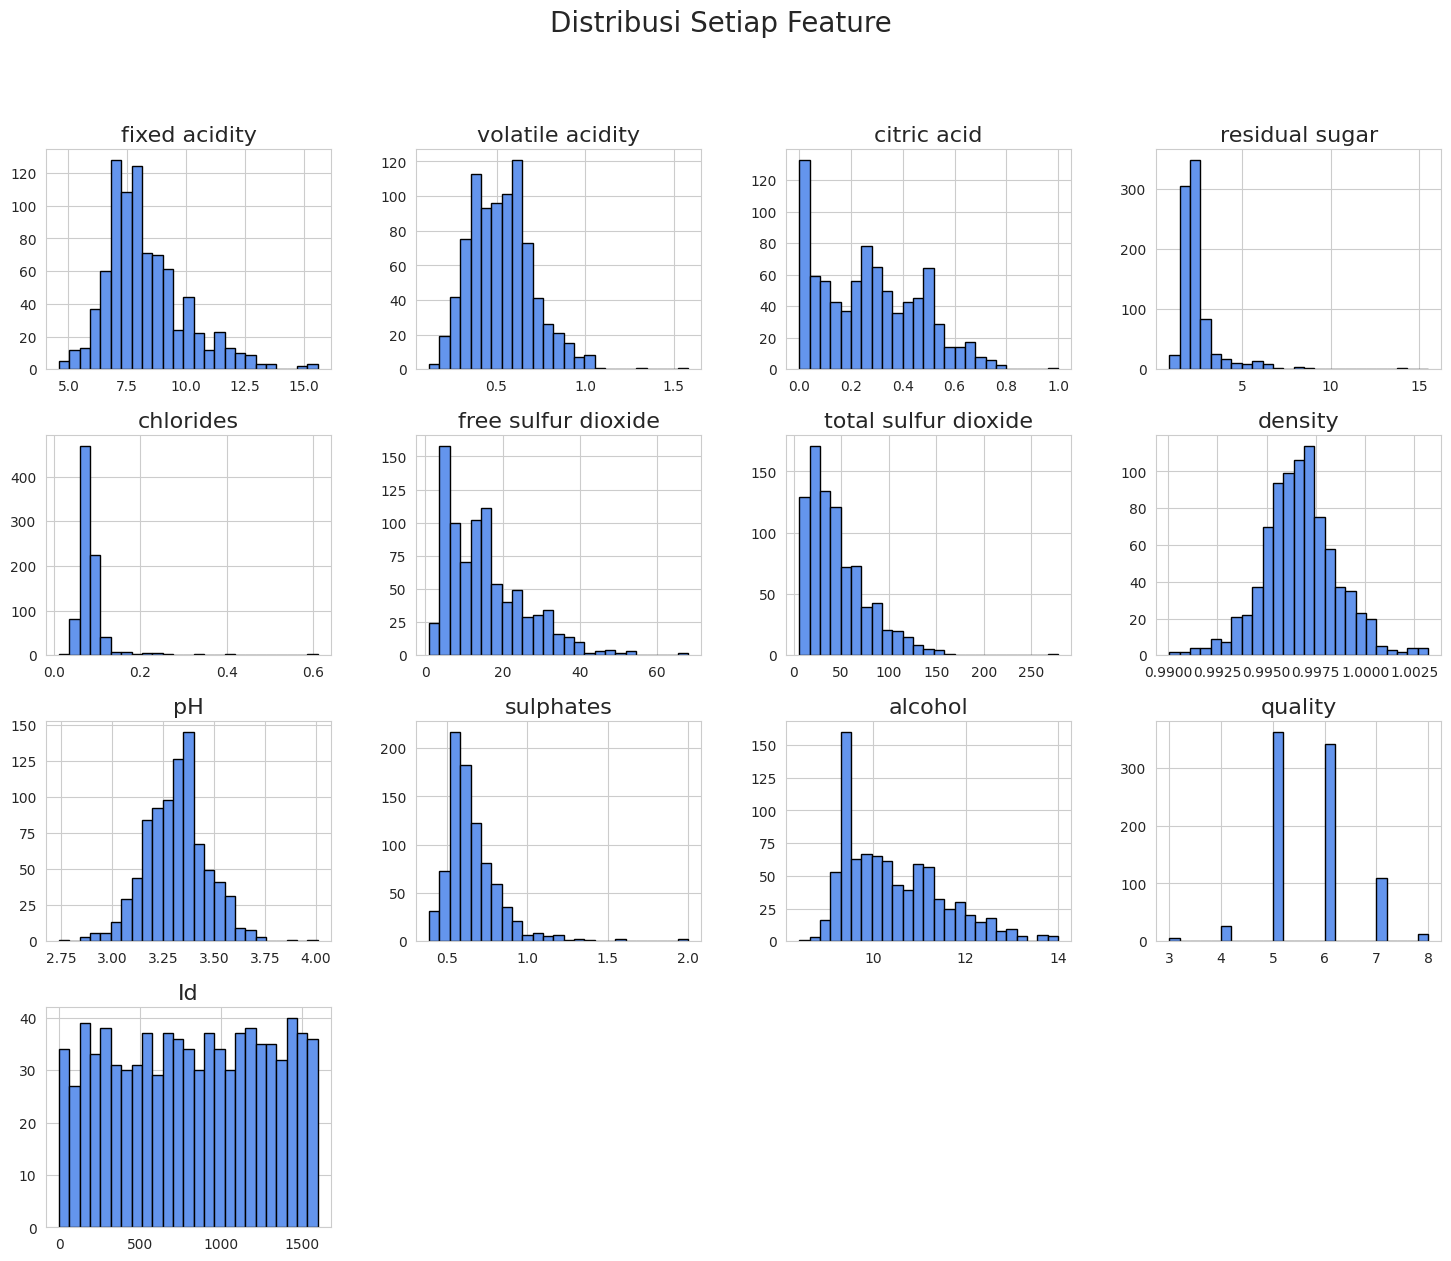

In [162]:
train_df.hist(
    figsize=(18,14),
    bins=25,
    color='cornflowerblue',
    edgecolor='black'
)

plt.suptitle(
    'Distribusi Setiap Feature',
    fontsize=20
)

plt.show()

Berdasarkan histogram distribusi setiap fitur, terlihat bahwa masing-masing variabel memiliki pola persebaran data yang berbeda-beda. Beberapa fitur menunjukkan distribusi yang mendekati normal, sementara beberapa fitur lainnya memiliki distribusi yang miring (*skewed*) dan mengandung nilai ekstrem (*outlier*).

Fitur seperti `density` dan `pH` memiliki distribusi yang relatif menyerupai distribusi normal karena data terkonsentrasi di sekitar nilai tengah dan membentuk pola menyerupai lonceng (*bell shape*). Hal ini menunjukkan bahwa sebagian besar data berada di sekitar rata-rata dan penyebarannya cukup stabil.

Sementara itu, fitur seperti `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, dan `sulphates` terlihat memiliki distribusi miring ke kanan (*positive skewness*). Kondisi ini menunjukkan bahwa sebagian besar data berada pada nilai rendah, namun terdapat beberapa data dengan nilai yang jauh lebih tinggi dibanding mayoritas data lainnya. Pola seperti ini mengindikasikan adanya kemungkinan *outlier*.

Pada fitur `fixed acidity`, `volatile acidity`, dan `alcohol`, distribusi data terlihat cukup menyebar dengan konsentrasi terbesar berada pada rentang nilai tertentu. Sebagian fitur juga menunjukkan adanya ekor distribusi yang panjang, yang menandakan variasi data cukup besar.

Histogram pada variabel `quality` menunjukkan bahwa kelas kualitas 5 dan 6 mendominasi dataset dibandingkan kelas lainnya. Hal ini memperkuat bahwa distribusi target bersifat tidak seimbang (*imbalanced*).


HEATMAP KORELASI

Selanjutnya adalah menganalisis hubungan antar variabel menggunakan *correlation heatmap*. Analisis korelasi bertujuan untuk mengetahui tingkat hubungan antar fitur dalam dataset, baik hubungan positif maupun negatif. Melalui analisis ini dapat diketahui fitur mana yang memiliki keterkaitan kuat terhadap variabel target maupun antar sesama fitur.

Visualisasi heatmap digunakan untuk mempermudah interpretasi nilai korelasi karena hubungan antar variabel ditampilkan dalam bentuk gradasi warna. Nilai korelasi berkisar dari -1 hingga 1, di mana nilai mendekati 1 menunjukkan hubungan positif yang kuat, nilai mendekati -1 menunjukkan hubungan negatif yang kuat, sedangkan nilai mendekati 0 menunjukkan hubungan yang lemah atau tidak terdapat hubungan linear.

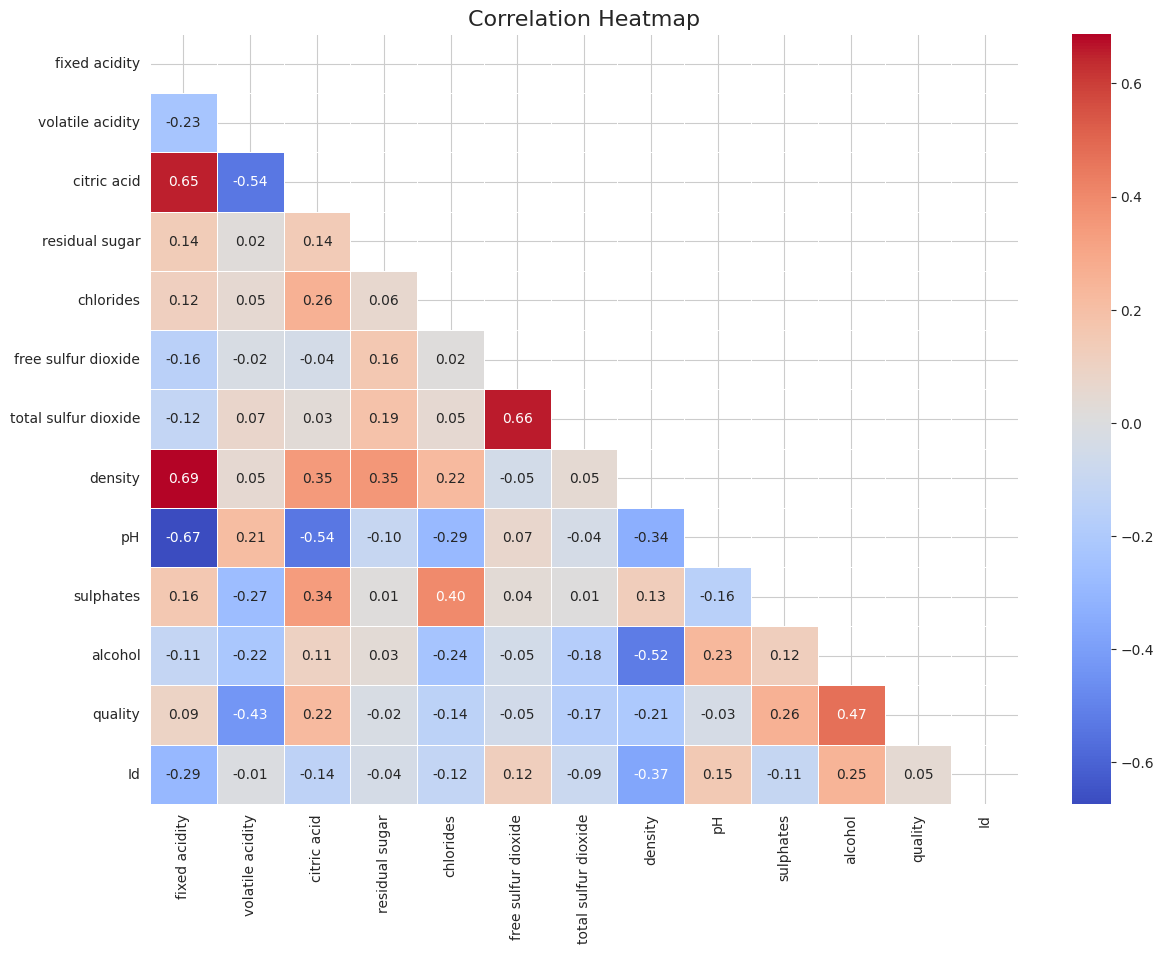

In [163]:
corr = train_df.corr()

plt.figure(figsize=(14,10))

mask = np.triu(np.ones_like(corr))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap')

plt.show()

Berdasarkan hasil *correlation heatmap*, terlihat bahwa setiap fitur memiliki tingkat korelasi yang berbeda-beda, baik hubungan positif maupun negatif. Nilai korelasi yang mendekati 1 menunjukkan hubungan positif yang kuat, sedangkan nilai yang mendekati -1 menunjukkan hubungan negatif yang kuat. Sementara itu, nilai yang mendekati 0 menunjukkan hubungan yang lemah antar variabel.

Pada heatmap terlihat bahwa fitur `alcohol` memiliki korelasi positif terbesar terhadap variabel `quality`, yaitu sebesar **0.47**. Hal ini menunjukkan bahwa semakin tinggi kadar alkohol pada wine, maka kualitas wine cenderung meningkat. Selain itu, fitur `citric acid` juga memiliki hubungan positif terhadap kualitas wine dengan nilai korelasi sebesar **0.22**.

Sebaliknya, fitur `volatile acidity` memiliki korelasi negatif cukup kuat terhadap `quality`, yaitu sebesar **-0.43**. Hal ini mengindikasikan bahwa semakin tinggi tingkat keasaman volatil, maka kualitas wine cenderung menurun. Fitur `density` juga memiliki korelasi negatif terhadap kualitas wine sebesar **-0.21**, meskipun hubungannya tidak terlalu kuat.

Selain hubungan terhadap target, terdapat beberapa hubungan kuat antar fitur. Misalnya:

* `fixed acidity` dan `density` memiliki korelasi positif cukup kuat sebesar **0.69**.
* `fixed acidity` dan `pH` memiliki korelasi negatif kuat sebesar **-0.67**.
* `free sulfur dioxide` dan `total sulfur dioxide` memiliki korelasi positif sebesar **0.66**.
* `citric acid` dan `volatile acidity` memiliki korelasi negatif sebesar **-0.54**.

Hubungan yang cukup tinggi antar fitur dapat mengindikasikan adanya *multicollinearity*, yaitu kondisi ketika beberapa fitur saling berkorelasi kuat. Kondisi ini perlu diperhatikan karena dapat mempengaruhi performa beberapa algoritma machine learning tertentu.

Secara keseluruhan, hasil heatmap menunjukkan bahwa fitur seperti `alcohol`, `volatile acidity`, dan `citric acid` memiliki pengaruh yang cukup signifikan terhadap kualitas wine. Informasi ini dapat digunakan sebagai dasar dalam proses seleksi fitur dan pembangunan model machine learning.


BOXPLOT OUTLIER

Selanjutnya adalah mendeteksi keberadaan outlier pada setiap variabel menggunakan visualisasi boxplot. Outlier merupakan data yang memiliki nilai jauh berbeda dari mayoritas data lainnya. Keberadaan outlier perlu diperhatikan karena dapat mempengaruhi hasil analisis statistik maupun performa model machine learning, terutama pada algoritma yang sensitif terhadap nilai ekstrem.

Visualisasi boxplot digunakan karena mampu menampilkan persebaran data secara ringkas melalui nilai minimum, kuartil, median, dan maksimum, serta memperlihatkan data yang berada di luar batas normal distribusi. Dengan menggunakan boxplot untuk setiap fitur, peneliti dapat mengidentifikasi variabel mana yang memiliki banyak outlier dan mempertimbangkan langkah preprocessing yang sesuai.

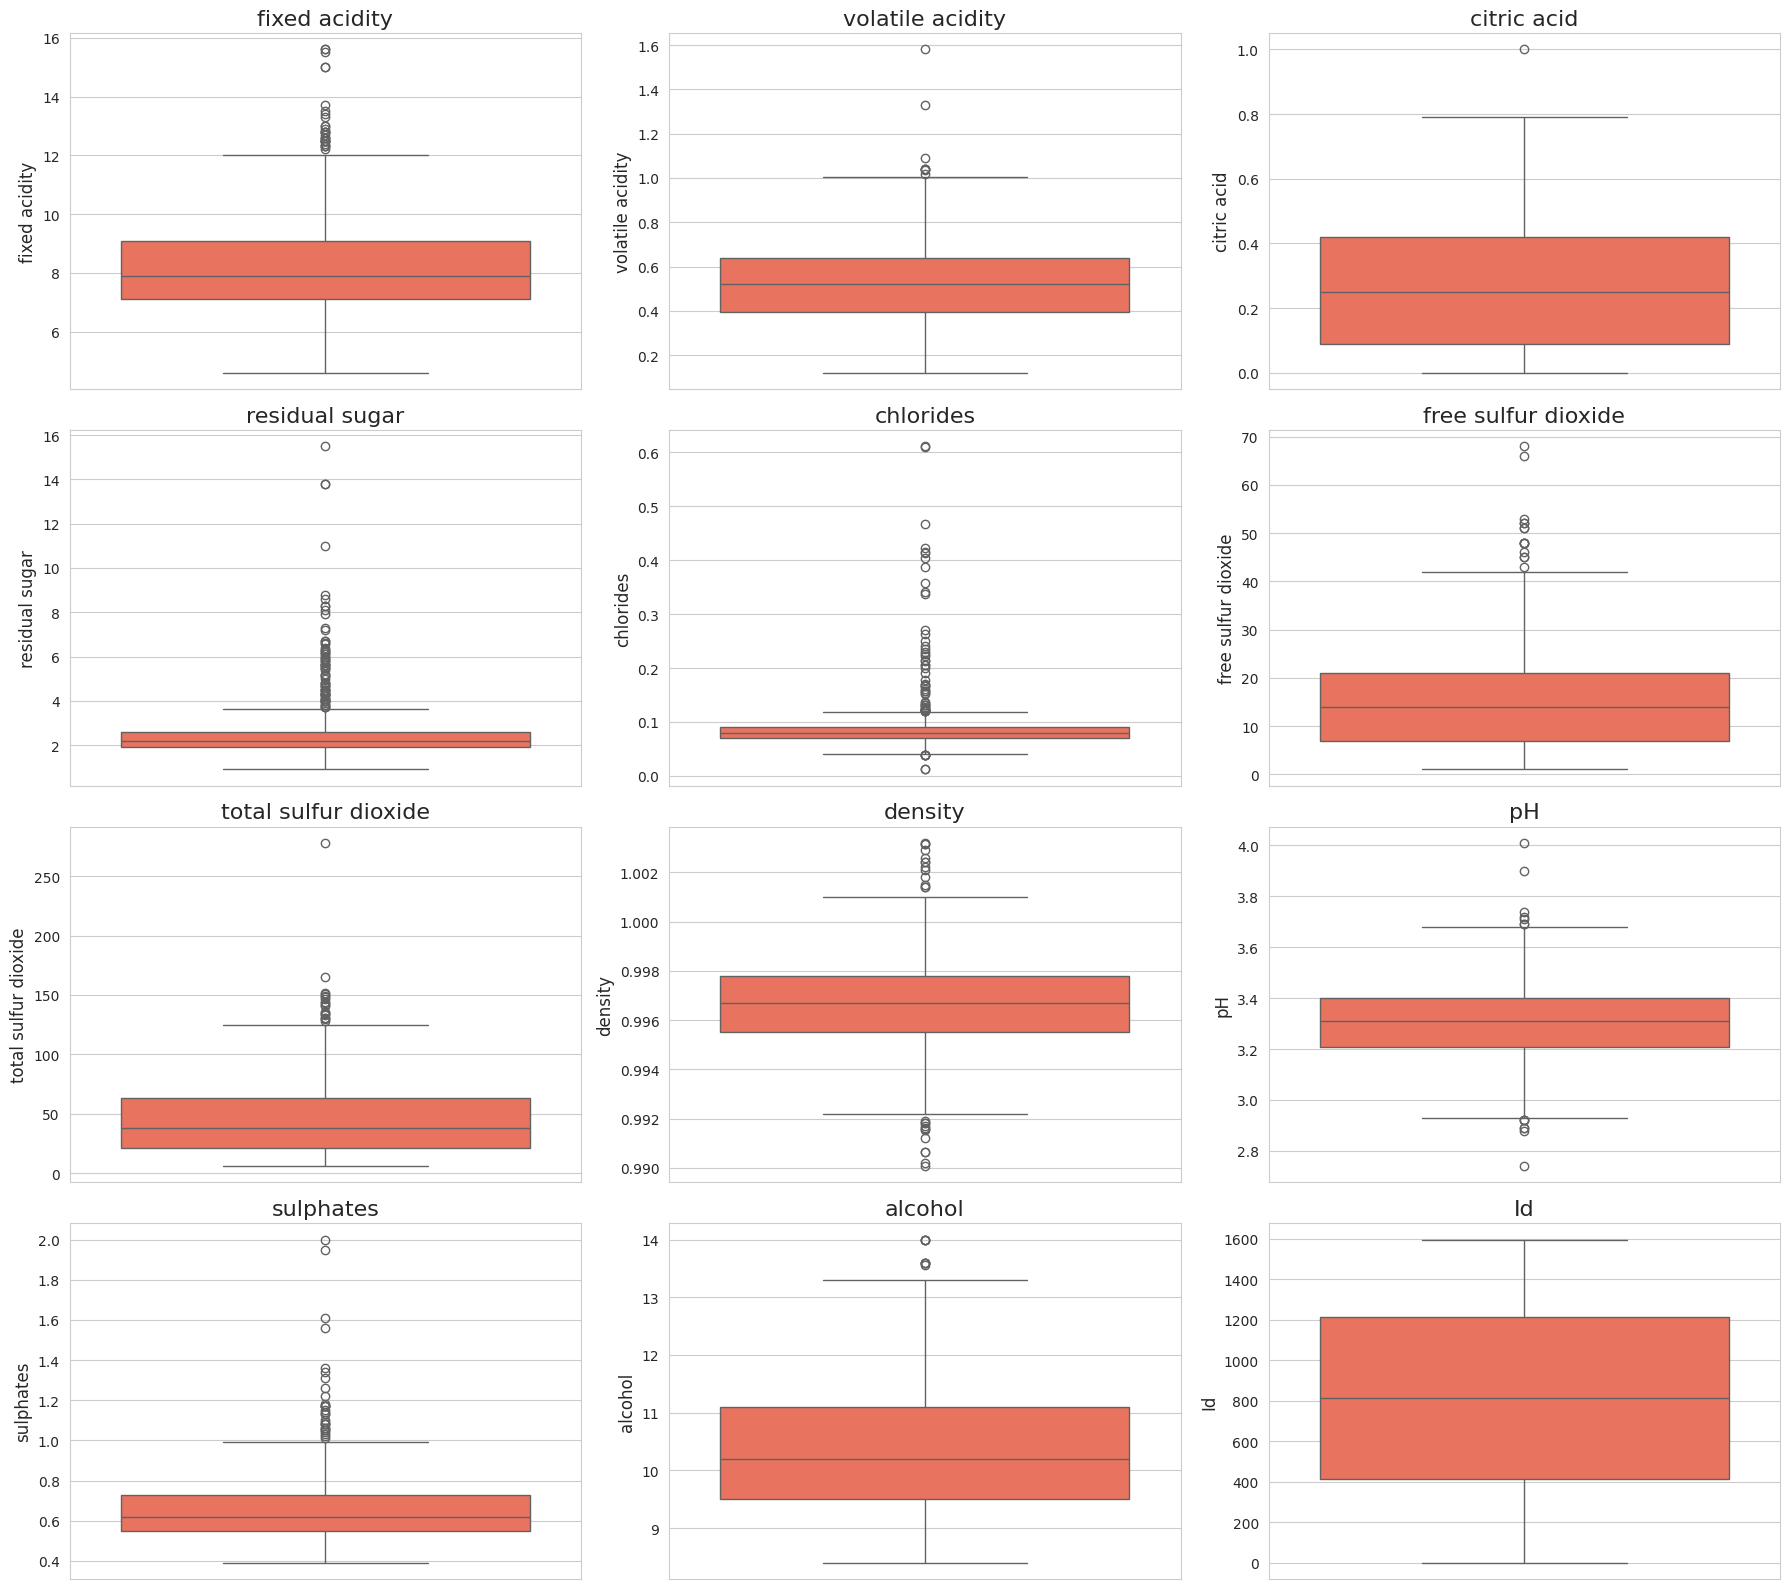

In [164]:
feature_cols = train_df.drop(
    'quality',
    axis=1
).columns

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(18,16)
)

axes = axes.flatten()

for ax, col in zip(axes, feature_cols):

    sns.boxplot(
        y=train_df[col],
        ax=ax,
        color='tomato'
    )

    ax.set_title(col)

plt.tight_layout()

plt.show()

Berdasarkan visualisasi boxplot pada setiap fitur, terlihat bahwa sebagian besar variabel memiliki sejumlah outlier atau data ekstrem yang berada di luar batas whisker boxplot. Outlier ditunjukkan oleh titik-titik yang berada di luar garis batas atas maupun bawah boxplot. Keberadaan outlier menunjukkan adanya data dengan nilai yang jauh berbeda dibanding mayoritas data lainnya.

Fitur residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, dan sulphates memiliki jumlah outlier yang cukup banyak, terutama pada nilai yang tinggi. Hal ini menunjukkan bahwa beberapa sampel wine memiliki kandungan gula, klorida, sulfur dioksida, maupun sulphates yang jauh lebih tinggi dibanding sebagian besar data lainnya. Kondisi tersebut sejalan dengan hasil histogram sebelumnya yang menunjukkan distribusi miring ke kanan (positive skewness).

Pada fitur fixed acidity dan volatile acidity, juga ditemukan beberapa outlier di bagian atas distribusi. Meskipun jumlahnya tidak sebanyak fitur lainnya, keberadaan data ekstrem tersebut tetap perlu diperhatikan karena dapat mempengaruhi performa model tertentu.

Fitur density dan pH terlihat memiliki persebaran data yang relatif lebih stabil dan simetris dibanding fitur lain. Namun, masih terdapat beberapa outlier pada kedua fitur tersebut, meskipun jumlahnya tidak terlalu signifikan.

Sementara itu, fitur alcohol menunjukkan beberapa nilai ekstrem pada kadar alkohol tinggi. Hal ini mengindikasikan adanya beberapa wine dengan kandungan alkohol yang jauh lebih tinggi dibanding mayoritas sampel.

PREPROCESSING

In [165]:
# =========================
# 1. DROP ID
# =========================

if 'Id' in train_df.columns:
    train_df.drop(columns=['Id'], inplace=True)

In [166]:
# =========================
# 2. TRANSFORM SKEWED FEATURE (LOG TRANSFORM)
# =========================

# fitur skewed berdasarkan EDA
skewed_features = [
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'sulphates'
]

# log transform
for col in skewed_features:

    if col in train_df.columns:
        train_df[col] = np.log1p(train_df[col])

Pada tahap ini dilakukan penanganan terhadap fitur yang memiliki distribusi miring (skewed) menggunakan metode log transformation. Berdasarkan hasil EDA sebelumnya, beberapa fitur seperti residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, dan sulphates menunjukkan distribusi yang tidak normal serta memiliki nilai ekstrem (outlier).

Transformasi logaritmik menggunakan np.log1p() diterapkan untuk mengurangi skewness, menstabilkan variansi data, serta mengurangi pengaruh outlier tanpa menghilangkan data asli. Fungsi log1p() digunakan karena lebih aman untuk data yang memiliki nilai nol, karena menghitung transformasi:

log(x+1)

Dengan transformasi ini, distribusi data menjadi lebih seimbang sehingga dapat membantu meningkatkan performa model machine learning pada tahap modeling.

In [167]:
# =========================
# 3. SPLIT FEATURE & TARGET
# =========================

X = train_df.drop('quality', axis=1)
y = train_df['quality']

Pada tahap ini dilakukan pemisahan antara fitur (feature) dan target (label) yang akan digunakan dalam proses machine learning. Variabel `X` berisi seluruh fitur prediktor pada dataset, sedangkan variabel `y` berisi target yang ingin diprediksi, yaitu `quality`.

Kolom `quality` dihapus dari `X` karena kolom tersebut merupakan label output yang akan dipelajari oleh model. Pemisahan ini penting agar model dapat mempelajari hubungan antara fitur-fitur input dengan kualitas wine yang menjadi target prediksi.


In [168]:
# =========================
# 4. TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Pada tahap ini dilakukan pembagian dataset menjadi data latih (*training set*) dan data uji (*testing set*) menggunakan fungsi `train_test_split()`. Data dibagi dengan proporsi 80% untuk data latih dan 20% untuk data uji (`test_size=0.2`).

Data latih digunakan untuk melatih model machine learning, sedangkan data uji digunakan untuk mengevaluasi performa model terhadap data yang belum pernah dilihat sebelumnya. Parameter `random_state=42` digunakan agar proses pembagian data konsisten setiap kali kode dijalankan.

Selain itu, digunakan parameter `stratify=y` untuk menjaga proporsi distribusi kelas pada target `quality` tetap seimbang antara data latih dan data uji, sehingga hasil evaluasi model menjadi lebih representatif.


In [169]:
# =========================
# 5. ROBUST SCALER
# =========================

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Pada tahap ini dilakukan proses scaling data menggunakan metode `RobustScaler`. Scaling bertujuan untuk menyamakan skala antar fitur agar model machine learning dapat bekerja lebih optimal dan tidak terpengaruh oleh perbedaan rentang nilai pada setiap fitur.

`RobustScaler` dipilih karena dataset masih memiliki beberapa outlier, sehingga metode ini lebih sesuai dibandingkan `StandardScaler`. RobustScaler bekerja menggunakan median dan interquartile range (IQR), sehingga lebih tahan terhadap pengaruh nilai ekstrem.

Proses `fit_transform()` dilakukan pada data latih (`X_train`) untuk mempelajari parameter scaling, sedangkan data uji (`X_test`) hanya menggunakan `transform()` agar tidak terjadi data leakage dari data uji ke data latih.


In [170]:
# =========================
# 6. HANDLE IMBALANCE (SMOTE)
# =========================

smote = SMOTE(
    random_state=42,
    k_neighbors=2
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

Pada tahap ini dilakukan penanganan ketidakseimbangan kelas (*imbalanced data*) menggunakan metode SMOTE (*Synthetic Minority Over-sampling Technique*). Berdasarkan hasil EDA sebelumnya, distribusi target `quality` menunjukkan bahwa beberapa kelas memiliki jumlah data yang jauh lebih sedikit dibandingkan kelas lainnya.

SMOTE bekerja dengan membuat data sintetis baru pada kelas minoritas sehingga distribusi data menjadi lebih seimbang. Dengan demikian, model machine learning dapat belajar lebih baik pada seluruh kelas dan tidak terlalu bias terhadap kelas mayoritas.

Parameter `k_neighbors=2` digunakan untuk menentukan jumlah tetangga terdekat yang digunakan dalam proses pembentukan data sintetis. Proses SMOTE hanya diterapkan pada data latih (`X_train_scaled` dan `y_train`) agar tidak terjadi data leakage pada data uji.


In [171]:
# =========================
# 7. CEK DISTRIBUSI KELAS
# =========================

print("Distribusi kelas setelah SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Distribusi kelas setelah SMOTE:
quality
5    289
6    289
7    289
4    289
8    289
3    289
Name: count, dtype: int64


Pada tahap ini dilakukan pengecekan distribusi kelas setelah penerapan metode SMOTE. Hasil yang diperoleh menunjukkan bahwa seluruh kelas pada target `quality` memiliki jumlah data yang sama, yaitu masing-masing sebanyak 289 data.

Sebelum dilakukan SMOTE, dataset memiliki kondisi *imbalanced*, di mana beberapa kelas seperti quality 3, 4, dan 8 memiliki jumlah data yang jauh lebih sedikit dibandingkan kelas lainnya. Setelah proses oversampling, distribusi kelas menjadi seimbang sehingga model machine learning dapat mempelajari setiap kelas secara lebih adil dan mengurangi kecenderungan model untuk terlalu fokus pada kelas mayoritas.


In [172]:
# =========================
# 8. CEK SHAPE DATA
# =========================

print("\nShape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)

print("\nShape setelah SMOTE:")
print(X_train_smote.shape)
print(y_train_smote.shape)


Shape X_train: (685, 11)
Shape X_test : (172, 11)

Shape setelah SMOTE:
(1734, 11)
(1734,)


Pada tahap ini dilakukan pengecekan ukuran (*shape*) data sebelum dan sesudah penerapan SMOTE. Hasil menunjukkan bahwa data latih (`X_train`) memiliki 685 baris data dengan 11 fitur, sedangkan data uji (`X_test`) memiliki 172 baris data dengan jumlah fitur yang sama.

Setelah dilakukan oversampling menggunakan SMOTE, jumlah data latih meningkat menjadi 1734 baris dengan tetap mempertahankan 11 fitur. Sementara itu, target hasil oversampling (`y_train_smote`) juga memiliki 1734 label.

Peningkatan jumlah data ini terjadi karena SMOTE menambahkan data sintetis pada kelas minoritas hingga seluruh kelas memiliki distribusi yang seimbang. Hal ini bertujuan agar model machine learning dapat belajar lebih optimal pada setiap kelas target.


MODELING

Pada tahap modeling, digunakan algoritma **XGBoost (Extreme Gradient Boosting)** untuk membangun model prediksi kualitas wine berdasarkan fitur-fitur kimia pada dataset. XGBoost merupakan salah satu algoritma machine learning berbasis boosting yang bekerja dengan membangun model secara bertahap untuk memperbaiki kesalahan dari model sebelumnya.

XGBoost dipilih karena memiliki performa yang baik pada data tabular, mampu menangani hubungan non-linear antar fitur, serta efektif dalam menangani permasalahan multiclass classification seperti prediksi kualitas wine. Selain itu, XGBoost juga dikenal lebih stabil dan memiliki kemampuan generalisasi yang baik dibandingkan beberapa algoritma machine learning lainnya.

Model kemudian dilatih menggunakan data hasil preprocessing yang telah melalui proses log transformation, scaling menggunakan RobustScaler, serta penanganan data imbalance menggunakan SMOTE. Setelah proses training selesai, performa model akan dievaluasi menggunakan metrik Accuracy, Precision, Recall, F1-Score, dan Confusion Matrix.


In [173]:
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)

EVALUATION

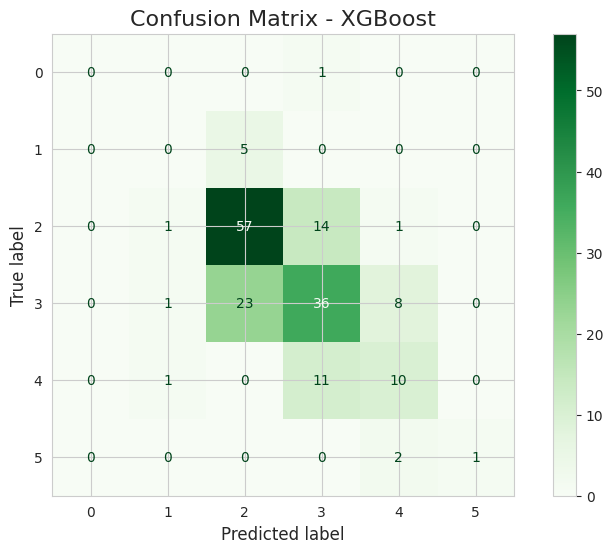

In [174]:
# =========================
# 1. CONFUSION MATRIX
# =========================

cm_xgb = confusion_matrix(
    y_test_indexed,
    y_pred_xgb
)

disp_xgb = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb
)

disp_xgb.plot(cmap='Greens')

plt.title("Confusion Matrix - XGBoost")
plt.show()

Berdasarkan hasil confusion matrix model XGBoost, dapat dilihat bahwa model sudah mampu melakukan klasifikasi kualitas wine dengan cukup baik, terutama pada kelas mayoritas. Hal ini terlihat dari nilai prediksi benar yang cukup tinggi pada beberapa kelas, khususnya kelas 2 yang memiliki jumlah prediksi benar paling banyak, yaitu sebanyak 57 data. Selain itu, kelas 3 juga menunjukkan hasil prediksi yang cukup baik dengan 36 prediksi benar. Namun, model masih mengalami kesalahan prediksi pada beberapa kelas yang memiliki karakteristik mirip, seperti kelas 2 yang sering diprediksi sebagai kelas 3, serta kelas 3 yang cukup sering diprediksi sebagai kelas 2 dan kelas 4. Kondisi ini menunjukkan adanya overlap antar kelas kualitas wine sehingga batas antar kelas menjadi sulit dipisahkan secara jelas oleh model.

Pada kelas minoritas, seperti kelas 0, 1, dan 5, performa model masih belum optimal karena jumlah data asli pada kelas tersebut relatif sedikit. Meskipun telah dilakukan penanganan imbalance menggunakan SMOTE, model masih kesulitan mempelajari pola pada kelas-kelas minoritas tersebut

In [175]:
# =========================
# 2. RECALL, PRECISION, ACCURACY, & F1-SCORE
# =========================

min_class_label = y_train_smote.min()

y_train_smote_indexed = y_train_smote - min_class_label
y_test_indexed = y_test - min_class_label

xgb_model.fit(X_train_smote, y_train_smote_indexed)

y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluate
accuracy = accuracy_score(y_test_indexed, y_pred_xgb)

precision = precision_score(
    y_test_indexed,
    y_pred_xgb,
    average='weighted'
)

recall = recall_score(
    y_test_indexed,
    y_pred_xgb,
    average='weighted'
)

f1 = f1_score(
    y_test_indexed,
    y_pred_xgb,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.6046511627906976
Precision: 0.5925174570953663
Recall   : 0.6046511627906976
F1-Score : 0.5934010620757134


Berdasarkan hasil evaluasi model XGBoost, diperoleh nilai accuracy sebesar 60,46%, yang menunjukkan bahwa model mampu memprediksi kualitas wine dengan benar pada sekitar 60% dari seluruh data uji. Nilai precision sebesar 59,25% menunjukkan bahwa prediksi yang dihasilkan model sudah cukup tepat dan memiliki tingkat kesalahan prediksi yang relatif moderat. Sementara itu, nilai recall sebesar 60,46% menunjukkan bahwa model cukup baik dalam mengenali dan menangkap data pada setiap kelas target.

Nilai F1-Score sebesar 59,34% menunjukkan keseimbangan yang cukup baik antara precision dan recall. Hasil ini menunjukkan bahwa model XGBoost sudah mampu mempelajari pola data dengan cukup baik meskipun dataset memiliki tantangan berupa multiclass classification, distribusi kelas yang tidak seimbang, serta adanya kemiripan karakteristik antar kelas kualitas wine

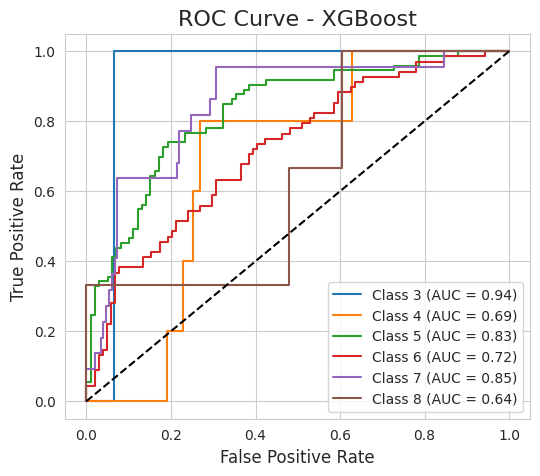

In [176]:
# =========================
# 3. ROC CURVE
# =========================

xgb_model.fit(X_train_smote, y_train_smote_indexed)
classes_indexed = sorted(y_test_indexed.unique())

y_test_bin = label_binarize(
    y_test_indexed,
    classes=classes_indexed
)

# probabilitas prediksi
y_score_xgb = xgb_model.predict_proba(
    X_test_scaled
)

# plot ROC Curve
plt.figure(figsize=(6,5))

for i in range(len(classes_indexed)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score_xgb[:, i]
    )

    roc_auc = auc(fpr, tpr)

    # Use original class labels for plotting
    original_class_label = classes_indexed[i] + min_class_label # Recover original label
    plt.plot(
        fpr,
        tpr,
        label=f'Class {original_class_label} (AUC = {roc_auc:.2f})'
    )

# garis diagonal
plt.plot([0,1], [0,1], 'k--')

plt.title("ROC Curve - XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

Berdasarkan grafik ROC Curve model XGBoost, dapat dilihat bahwa kemampuan model dalam membedakan setiap kelas kualitas wine cukup bervariasi. Nilai AUC (Area Under Curve) digunakan untuk mengukur seberapa baik model membedakan suatu kelas dengan kelas lainnya. Semakin mendekati nilai 1, maka performa model pada kelas tersebut semakin baik.

Kelas 3 memiliki performa terbaik dengan nilai AUC sebesar 0,94, yang menunjukkan bahwa model sangat baik dalam mengenali data pada kelas tersebut. Selain itu, kelas 7 dan kelas 5 juga menunjukkan performa yang baik dengan nilai AUC masing-masing sebesar 0,85 dan 0,83. Hal ini menunjukkan bahwa model cukup mampu membedakan pola data pada kelas-kelas tersebut dibandingkan kelas lainnya.

Sementara itu, kelas 6 memiliki performa sedang dengan nilai AUC sebesar 0,72, yang menunjukkan bahwa model masih cukup baik dalam melakukan klasifikasi meskipun masih terdapat beberapa kesalahan prediksi. Pada kelas 4 dan kelas 8, nilai AUC relatif lebih rendah, yaitu sebesar 0,69 dan 0,64. Hal ini menunjukkan bahwa model masih mengalami kesulitan dalam membedakan kelas-kelas tersebut, kemungkinan karena jumlah data yang lebih sedikit serta adanya kemiripan karakteristik fitur dengan kelas lain.

PREDIKSI DATA UJI

In [177]:
# =========================
# PREDIKSI DATA TESTING
# =========================

test_prediction = xgb_model.predict(
    X_test_scaled
)

print(test_prediction[:10])

[2 2 2 2 4 2 2 2 3 3]


In [178]:
# =========================
# PREDIKSI DATA TESTING
# =========================

# Copy data testing
test_copy = test_df.copy()

# Log transform
for col in skewed_features:
    test_copy[col] = np.log1p(test_copy[col])

# Ambil Id
test_ids = test_copy['Id']

# Hapus Id
X_test = test_copy.drop('Id', axis=1)

# Scaling
X_test_scaled = scaler.transform(X_test)

# Prediksi
test_prediction = xgb_model.predict(X_test_scaled)

# Kembalikan label asli
test_prediction = test_prediction + min_class_label

# Submission
submission = pd.DataFrame({
    'Id': test_ids,
    'Quality': test_prediction
})

submission.head()

,Id,Quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5


In [179]:
# =========================
# EXPORT CSV
# =========================

submission.to_csv(
    'hasilprediksi_011.csv',
    index=False
)

print("File berhasil disimpan")

File berhasil disimpan


In [180]:
# =========================
# DOWNLOAD FILE
# =========================

from google.colab import files

files.download(
    'hasilprediksi_011.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>